In [1]:
import anndata as ad
import pandas as pd
import scanpy as sc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import numpy as np
import anndata as ad
import h5py
import scvelo as scv
import warnings

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="No data for colormapping provided via 'c'")
# set once in the main process
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*na_action.*Categorical\.map.*",
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r"No data for colormapping provided via 'c'.*cmap.*",)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)

In [3]:
gray_green = LinearSegmentedColormap.from_list(
    "gray_green", ["#D3D3D3", "#02500e", "#001203"]
)
gray_orange = LinearSegmentedColormap.from_list(
    "gray_orange", ["#D3D3D3", "#f76d48", "#FA4616"]
)

In [5]:
adata_transformed = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/adata_weird_clustered_(40,24)_(0.0005,1.7)_8_5_25.h5ad")

In [6]:
#importing subset from loupe
barcodes = pd.read_csv("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/combined_samples_scvelo/data/external/epi_coords_adata_weird_clustered_(40,24)_(0.0005,1.7)_8_5_25.csv")["Barcode"].tolist()
sample_number_to_prefix_and_sample = {
    "1": ("plus4_v5e_062522_forced6k_possorted_genome_bam_CRXMJ", "p4"),
    "2": ("plus345_1_v5e_062522_forced6k_possorted_genome_bam_RL5DI", "p5_1"),
    "3": ("plus345_2_v5e_062522_forced6k_possorted_genome_bam_6EON9", "p5_2"),
    "4": ("minus4_v5e_062522_forced6k_possorted_genome_bam_GWFTD", "m4"),
    "5": ("minus345_2_v5e_062522_forced6k_possorted_genome_CEA3D", "m5")
}

def convert_barcode(bc):
    barcode_part, sample_number = bc.split("-")
    prefix, sample = sample_number_to_prefix_and_sample[sample_number]
    return f"{prefix}:{barcode_part}x"

barcodes_full = pd.Series(barcodes).apply(convert_barcode).tolist()
adata_subset = adata_transformed[adata_transformed.obs_names.isin(barcodes_full)].copy()

In [8]:
adata = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/raw/combined_adata_raw_2.h5ad")

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(values):


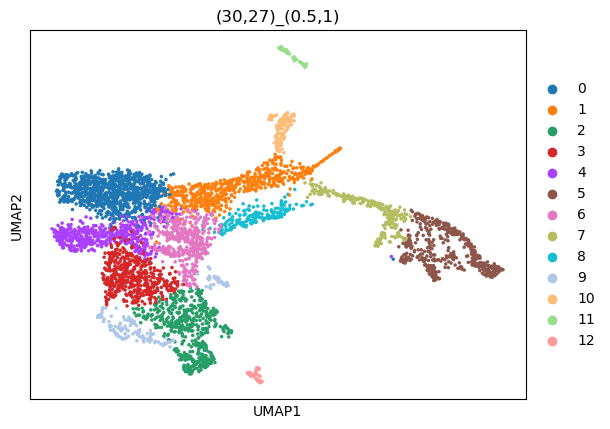

In [28]:
#final subset UMAP
n_pcs=30
n_neighbors=27
min_dist=.5
spread=1
seed=13
adata_subset_test=adata_subset.copy()
sc.tl.pca(adata_subset_test, n_comps=50, svd_solver='arpack',random_state=seed)
sc.pp.neighbors(adata_subset_test, n_pcs=n_pcs, n_neighbors=n_neighbors,random_state=seed)  
sc.tl.umap(adata_subset_test,min_dist=min_dist,spread=spread,random_state=seed)
sc.tl.leiden(adata_subset_test, resolution=0.5,random_state=seed)
sc.pl.umap(adata_subset_test, color="leiden", cmap="viridis", title=f"({n_pcs},{n_neighbors})_({min_dist},{spread})",#legend_loc="on data",
         #save=f"_subset_combined_umap.pdf 
          )

In [29]:
adata_subset_test

AnnData object with n_obs × n_vars = 4655 × 2000
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'scrublet_score_zscore_0p04_pc35', 'scrublet_pred_zscore_0p04_pc35', 'scrublet_score_zscore_0p06_pc35', 'scrublet_pred_zscore_0p06_pc35', 'scrublet_score_zscore_0p08_pc35', 'scrublet_pred_zscore_0p08_pc35', 'scrublet_score_zscore_0p1_pc35', 'scrublet_pred_zscore_0p1_pc35', 'scrublet_score_zscore_0p04_pc40', 'scrublet_pred_zscore_0p04_pc40', 'scrublet_score_zscore_0p06_pc40', 'scrublet_pred_zscore_0p06_pc40', 'scrublet_score_zscore_0p08_pc40', 'scrublet_pred_zscore_0p08_pc40', 'scrublet_score_zscore_0p1_pc40', 'scrublet_pred_zscore_0p1_pc40', 'scrublet_score_zscore_0p04_pc45', 'scrublet_pred_zscore_0p04_pc45', 'scrublet_score_zscore_0p06_pc45', 'scrublet_pred_zscore_0p06_pc45', 'scrublet_score_zscore_0p0

In [30]:
adata_sub_velo=adata_subset_test.copy()

In [31]:
adata_raw = adata.copy() 
adata_raw = adata_raw[adata_sub_velo.obs_names, :].copy()
adata_raw = adata_raw[:, adata_sub_velo.var_names].copy()
adata_raw.obsm["X_umap"] = adata_sub_velo.obsm["X_umap"]
adata_raw.obs["leiden"]  = adata_sub_velo.obs["leiden"]

In [32]:
adata_velocity=adata_raw.copy()

Filtered out 593 genes that are detected 20 counts (spliced).
Normalized count data: X, spliced, unspliced.


/scratch/local/9436980/ipykernel_1982280/3561746621.py:9: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata_velocity, n_pcs=24, n_neighbors=36)
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute PCA with Scanpy first.
  _set_pca(adata=adata, n_pcs=n_pcs, use_highly_variable=use_highly_variable)


computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 1/128 cores)
    finished (0:05:17) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:01) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 8/128 cores)
    finished (0:00:06) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


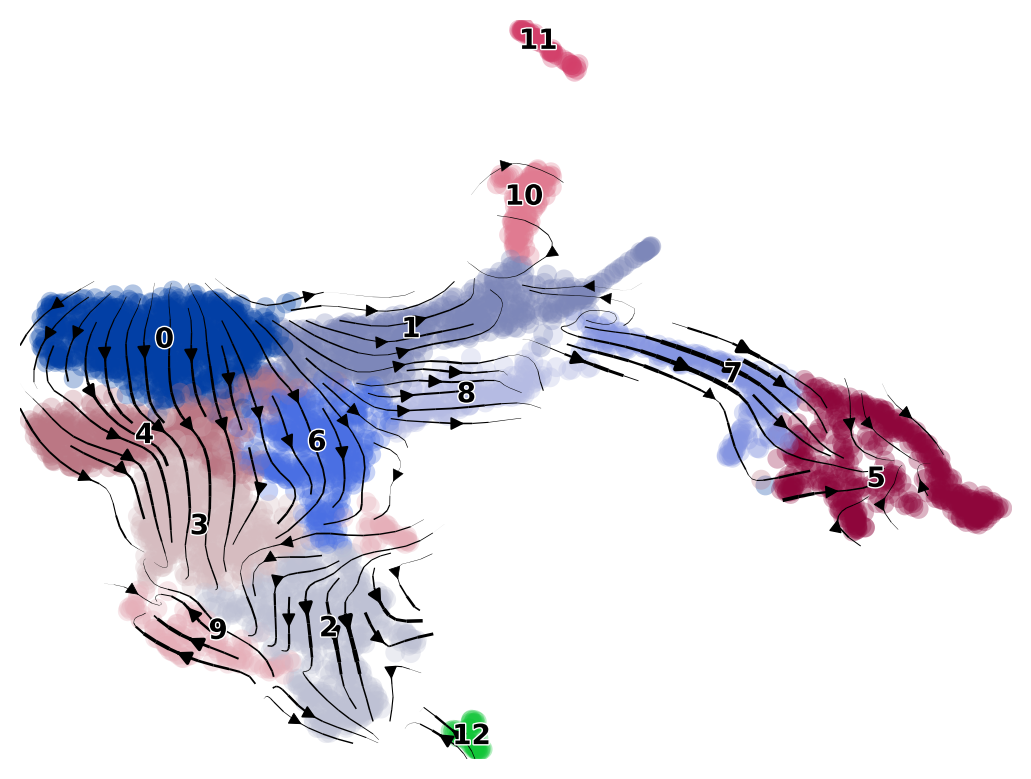

In [35]:
adata_velocity=adata_raw.copy()
scv.pp.filter_and_normalize(
    adata_velocity,
    min_counts=20,
    min_cells=5,
    n_top_genes=None, 
    log=False
)
scv.pp.moments(adata_velocity, n_pcs=24, n_neighbors=36)
scv.tl.recover_dynamics(adata_velocity)
scv.tl.velocity(adata_velocity, mode="dynamical", n_jobs=8)
scv.tl.velocity_graph(adata_velocity, n_jobs=8)
scv.pl.velocity_embedding_stream(adata_velocity, basis='umap',dpi=200,color="leiden", title="",
                                 #save="plus345_2_subset_velocity_stream_grey.svg"
                                )